# Analyse Prédictive du Statut des Clients d'une Banque
## By SMA!L

In [47]:
pip install pyreadstat

Note: you may need to restart the kernel to use updated packages.


In [48]:
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [49]:
df, meta = pyreadstat.read_sav("scoring.sav")

In [50]:
df.head(10)

,Age,Marital,Expenses,Income,Amount,Price,Statut1
0,30.0,2.0,73.0,129.0,800.0,846.0,0.0
1,58.0,3.0,48.0,131.0,1000.0,1658.0,0.0
2,46.0,2.0,90.0,200.0,2000.0,2985.0,1.0
3,24.0,1.0,63.0,182.0,900.0,1325.0,0.0
4,26.0,1.0,46.0,107.0,310.0,910.0,0.0
5,36.0,2.0,75.0,214.0,650.0,1645.0,0.0
6,44.0,2.0,75.0,125.0,1600.0,1800.0,0.0
7,27.0,1.0,35.0,80.0,200.0,1093.0,0.0
8,32.0,2.0,90.0,107.0,1200.0,1957.0,0.0
9,41.0,2.0,90.0,80.0,1200.0,1468.0,1.0


In [51]:
df['Statut1'] = df['Statut1'].map({0: 'Solvable', 1: 'Non solvable'})

In [52]:
df.head(10)

,Age,Marital,Expenses,Income,Amount,Price,Statut1
0,30.0,2.0,73.0,129.0,800.0,846.0,Solvable
1,58.0,3.0,48.0,131.0,1000.0,1658.0,Solvable
2,46.0,2.0,90.0,200.0,2000.0,2985.0,Non solvable
3,24.0,1.0,63.0,182.0,900.0,1325.0,Solvable
4,26.0,1.0,46.0,107.0,310.0,910.0,Solvable
5,36.0,2.0,75.0,214.0,650.0,1645.0,Solvable
6,44.0,2.0,75.0,125.0,1600.0,1800.0,Solvable
7,27.0,1.0,35.0,80.0,200.0,1093.0,Solvable
8,32.0,2.0,90.0,107.0,1200.0,1957.0,Solvable
9,41.0,2.0,90.0,80.0,1200.0,1468.0,Non solvable


In [53]:
df.dtypes

Age         float64
Marital     float64
Expenses    float64
Income      float64
Amount      float64
Price       float64
Statut1      object
dtype: object

In [54]:
cols_a_convertir = ['Age', 'Marital']
df[cols_a_convertir] = df[cols_a_convertir].astype(int)


In [55]:
df.dtypes

Age           int64
Marital       int64
Expenses    float64
Income      float64
Amount      float64
Price       float64
Statut1      object
dtype: object

##### Identifier et analyser les valeurs manquantes dans chaque variable. 

In [56]:
print(df.isnull().sum())

Age         0
Marital     0
Expenses    0
Income      0
Amount      0
Price       0
Statut1     0
dtype: int64


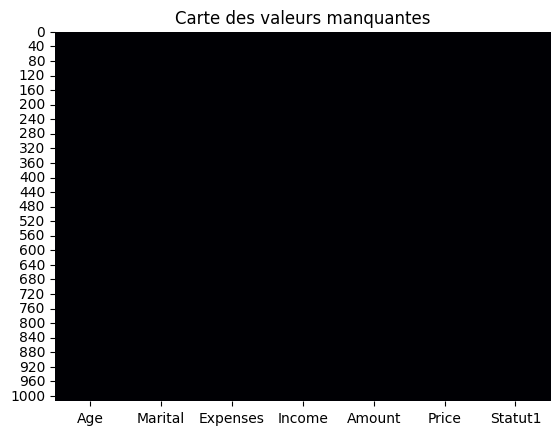

In [57]:
sns.heatmap(df.isnull(), cbar=False, cmap='inferno')
plt.title("Carte des valeurs manquantes")
plt.show()

### EDA

In [58]:
# stats détaillées par variable
for col in ['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']:
    print(f"| Variable : {col}")
    print("  Effectif :", df[col].count())
    print("  Moyenne :", df[col].mean())
    print("  Écart-type :", df[col].std())
    print("  Médiane :", df[col].median())
    print("  Q1 :", df[col].quantile(0.25))
    print("  Q3 :", df[col].quantile(0.75))
    print("  Valeurs uniques :", df[col].nunique())
    print("-" * 40)

| Variable : Age
  Effectif : 1015
  Moyenne : 37.902463054187194
  Écart-type : 10.967287913782124
  Médiane : 36.0
  Q1 : 29.0
  Q3 : 46.0
  Valeurs uniques : 50
----------------------------------------
| Variable : Marital
  Effectif : 1015
  Moyenne : 1.8985221674876847
  Écart-type : 0.5896441805161814
  Médiane : 2.0
  Q1 : 2.0
  Q3 : 2.0
  Valeurs uniques : 5
----------------------------------------
| Variable : Expenses
  Effectif : 1015
  Moyenne : 61.765517241379314
  Écart-type : 20.779157008399835
  Médiane : 60.0
  Q1 : 45.0
  Q3 : 75.0
  Valeurs uniques : 77
----------------------------------------
| Variable : Income
  Effectif : 1015
  Moyenne : 150.50541871921183
  Écart-type : 98.39681225993155
  Médiane : 133.0
  Q1 : 96.5
  Q3 : 185.0
  Valeurs uniques : 236
----------------------------------------
| Variable : Amount
  Effectif : 1015
  Moyenne : 1034.7458128078817
  Écart-type : 452.83327698532787
  Médiane : 1000.0
  Q1 : 750.0
  Q3 : 1300.0
  Valeurs uniques : 1

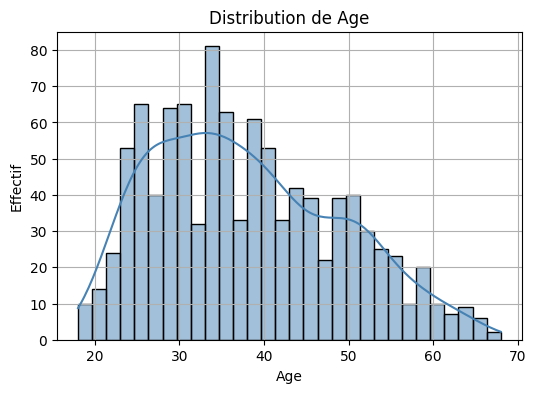

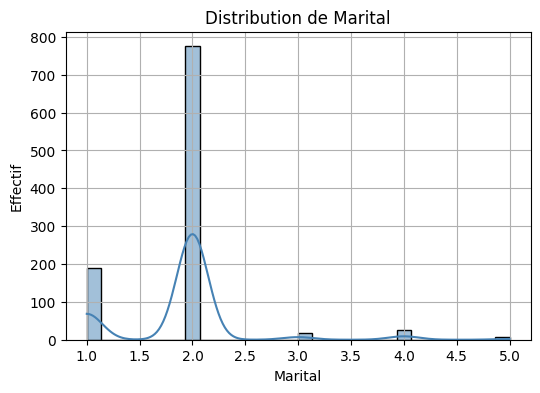

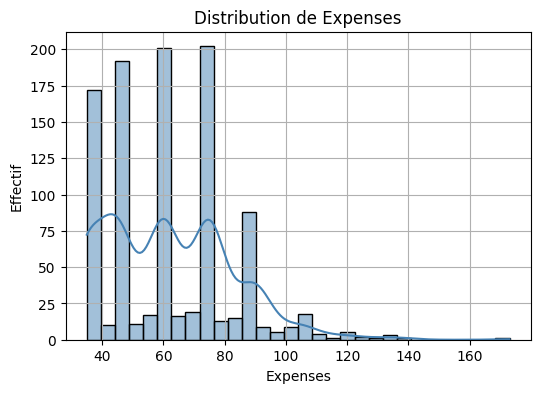

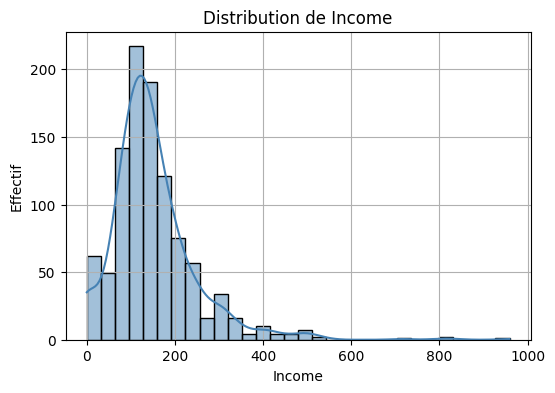

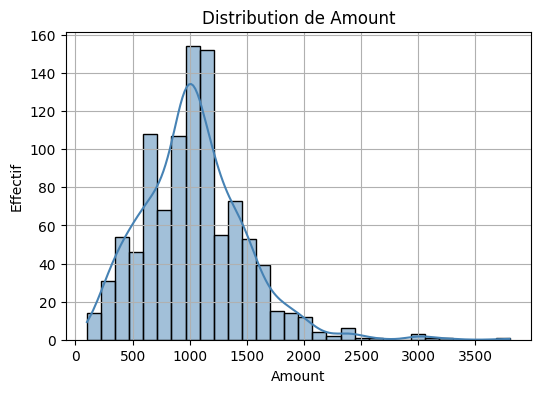

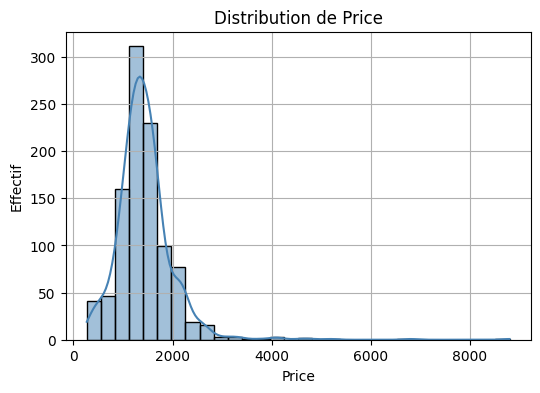

In [59]:
# histos avec courbe KDE
for col in ['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.grid(True)
    plt.show()

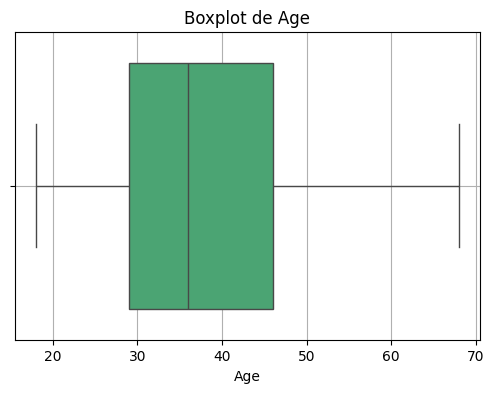

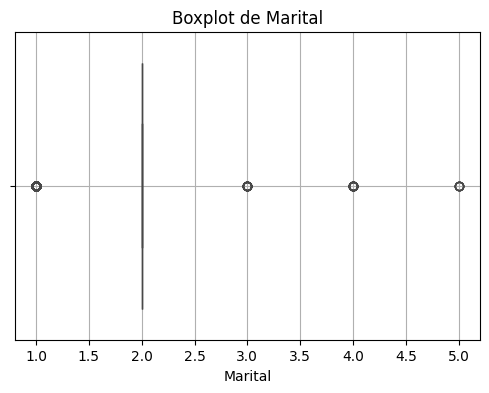

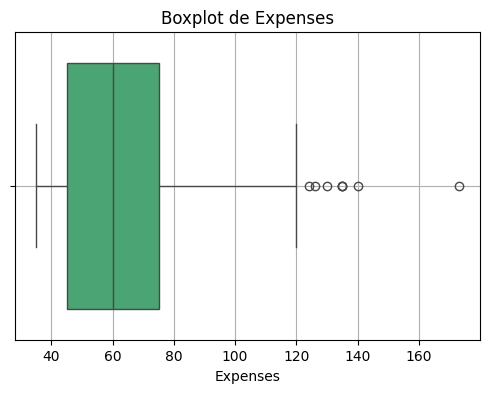

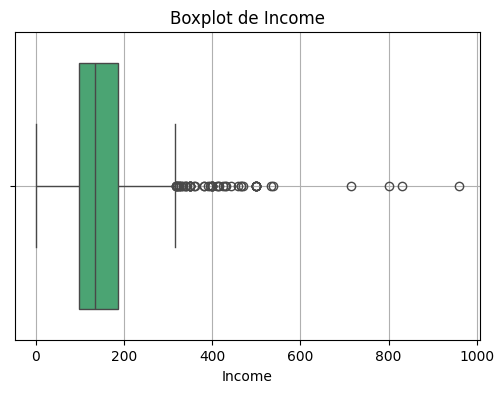

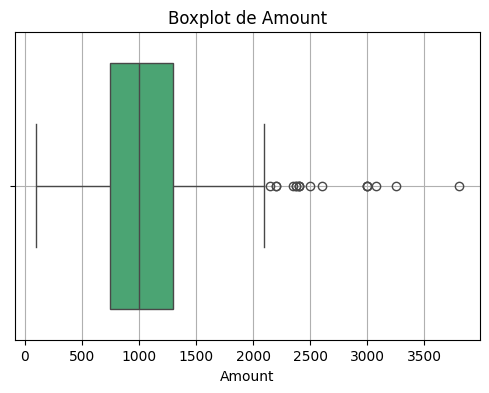

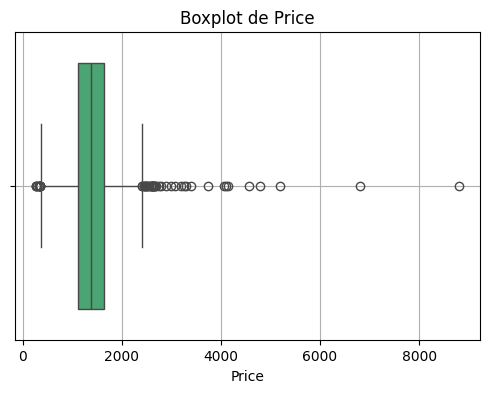

In [60]:
# boxplots
for col in ['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='mediumseagreen')
    plt.title(f'Boxplot de {col}')
    plt.grid(True)
    plt.show()

In [61]:
# Rq: il y a plusieurs valeurs aberrantes pour differentes variables


Effectifs de Statut1 :
Statut1
Solvable        742
Non solvable    273
Name: count, dtype: int64


C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\4097233402.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Statut1', data=df, palette='pastel')


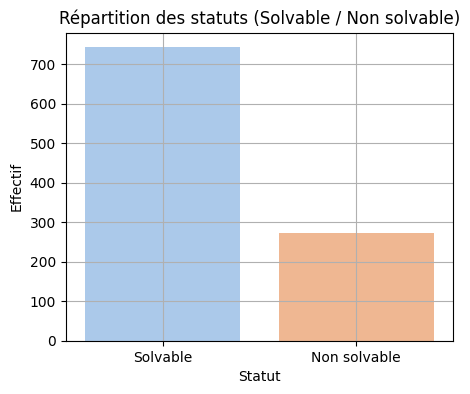

In [62]:
# analyse de Statut1
print("\nEffectifs de Statut1 :")
print(df['Statut1'].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x='Statut1', data=df, palette='pastel')
plt.title("Répartition des statuts (Solvable / Non solvable)")
plt.xlabel("Statut")
plt.ylabel("Effectif")
plt.grid(True)
plt.show()

In [63]:
## relations entre la variable cible (Statut1) et les variables explicatives

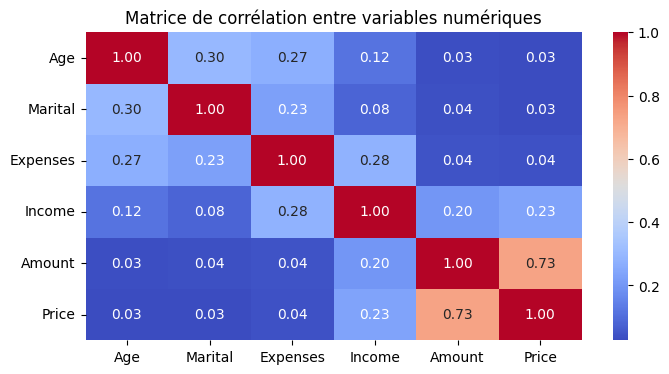

In [64]:
plt.figure(figsize=(8, 4))
corr = df[['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation entre variables numériques")
plt.show()

In [65]:
# ANOVA

In [66]:
import scipy.stats as stats

In [67]:
# Test ANOVA entre Statut1 et variables numériques
for col in ['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']:
    solvable = df[df['Statut1'] == 'Solvable'][col].dropna()
    nonsolvable = df[df['Statut1'] == 'Non solvable'][col].dropna()
    stat, p = stats.f_oneway(solvable, nonsolvable)
    print(f"{col}: F-stat = {stat:.2f}, p-value = {p:.4f}")

Age: F-stat = 11.09, p-value = 0.0009
Marital: F-stat = 0.47, p-value = 0.4938
Expenses: F-stat = 0.04, p-value = 0.8329
Income: F-stat = 42.60, p-value = 0.0000
Amount: F-stat = 22.23, p-value = 0.0000
Price: F-stat = 0.02, p-value = 0.8836


In [68]:
## pour Age, Income, Amount  on peut dire qu'elles sont probablement pertinentes pour distinguer entre solvable et non-solvable

C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\3805768121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')


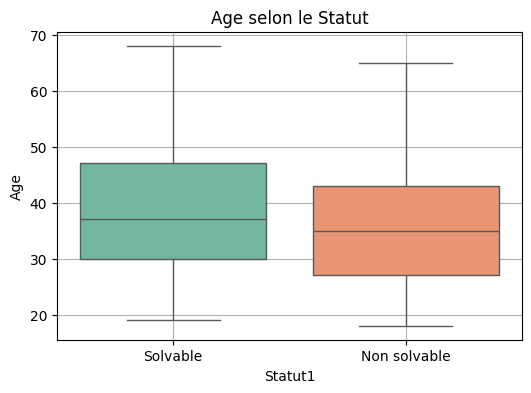

C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\3805768121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')


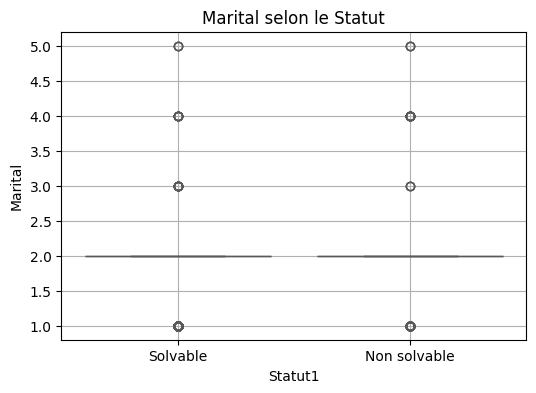

C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\3805768121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')


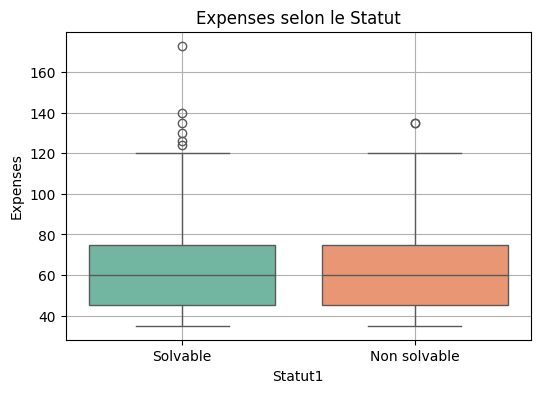

C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\3805768121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')


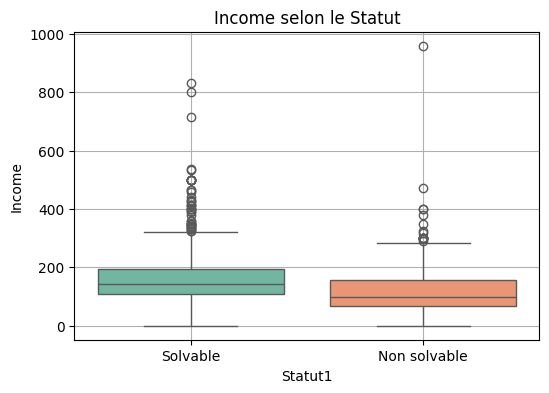

C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\3805768121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')


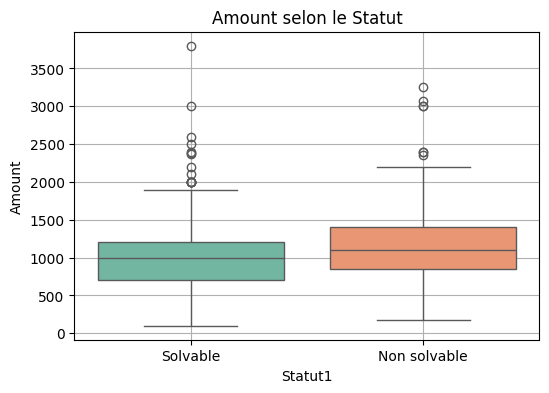

C:\Users\PARAV\AppData\Local\Temp\ipykernel_20552\3805768121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')


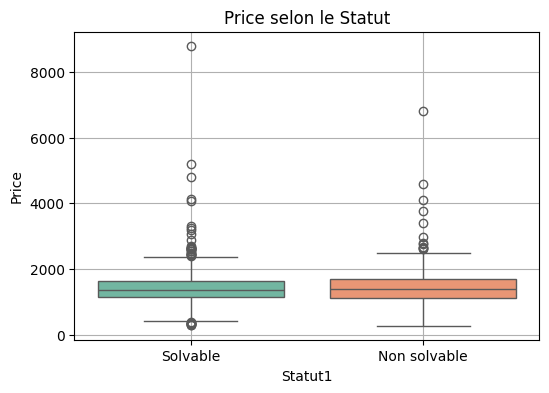

In [69]:
# boxplots groupés par Statut
for col in ['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Statut1', y=col, data=df, palette='Set2')
    plt.title(f'{col} selon le Statut')
    plt.grid(True)
    plt.show()


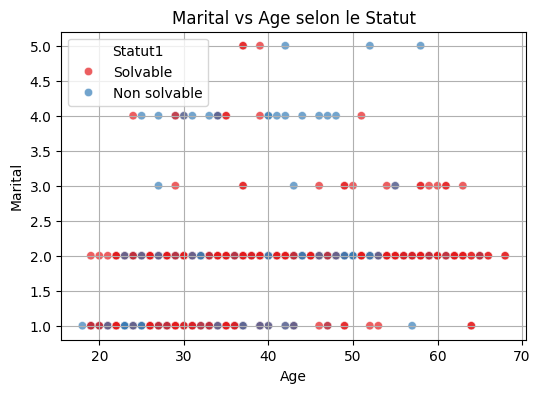

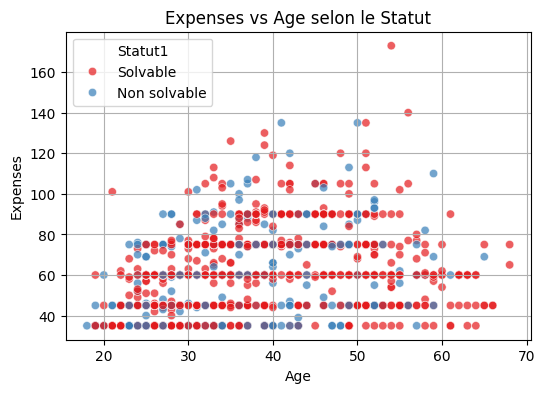

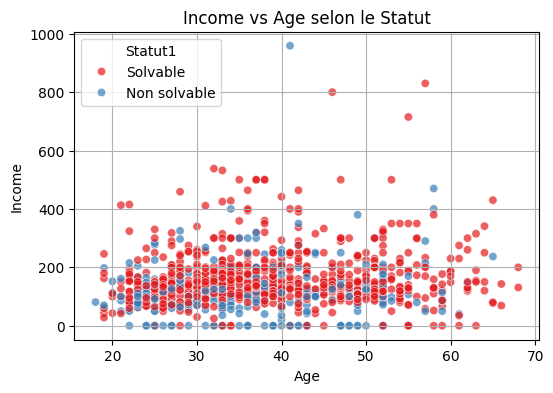

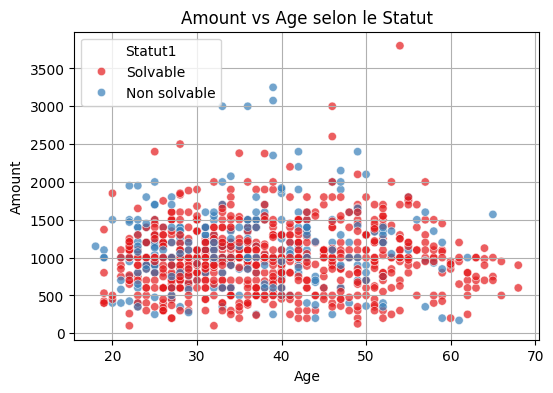

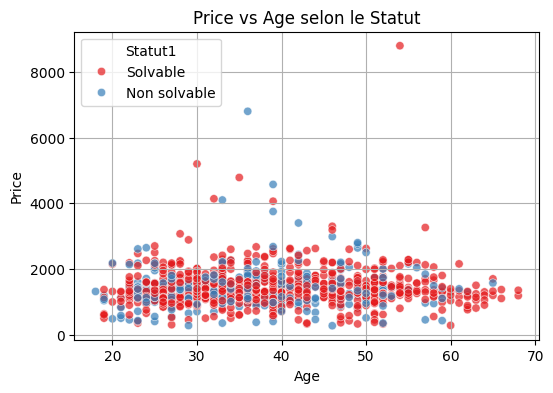

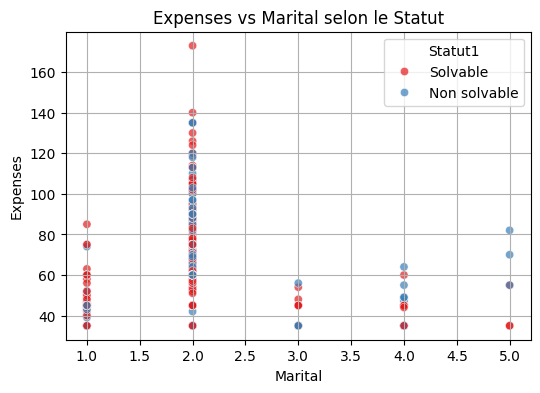

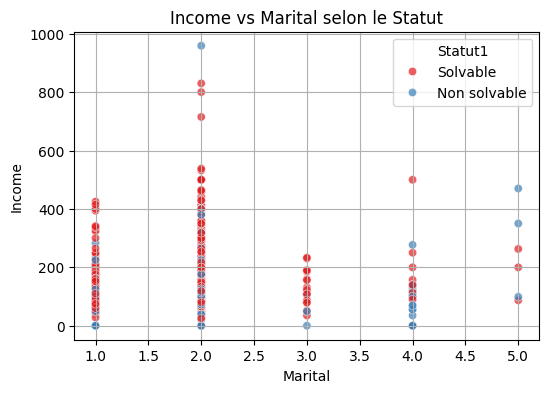

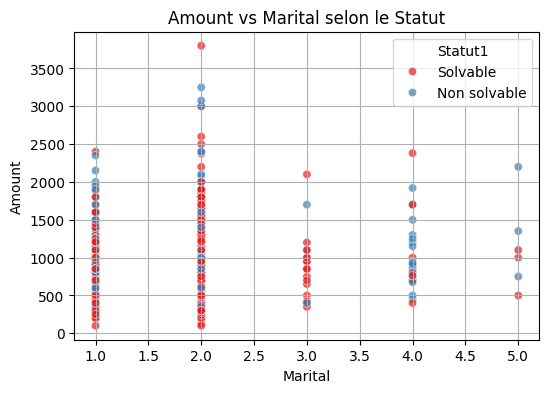

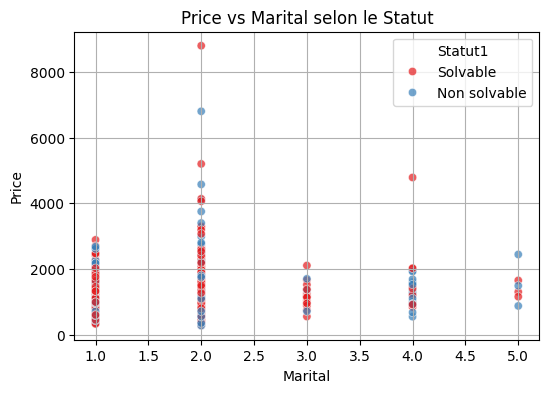

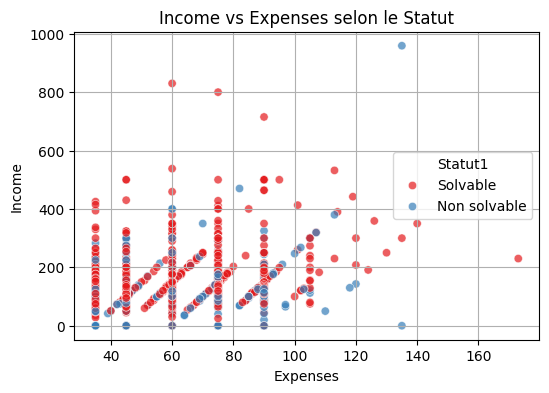

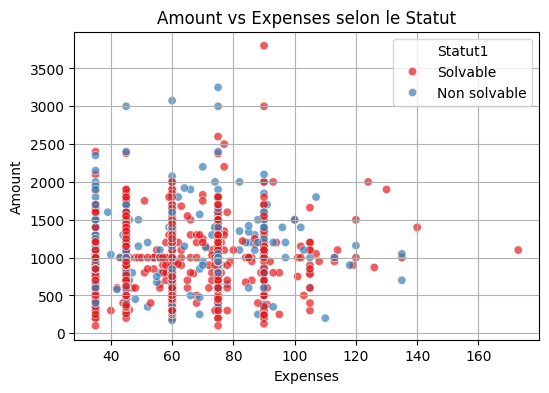

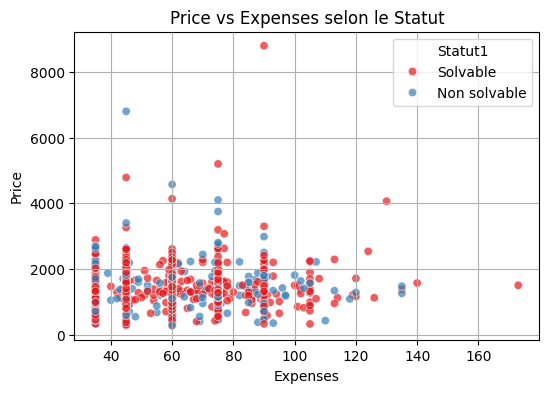

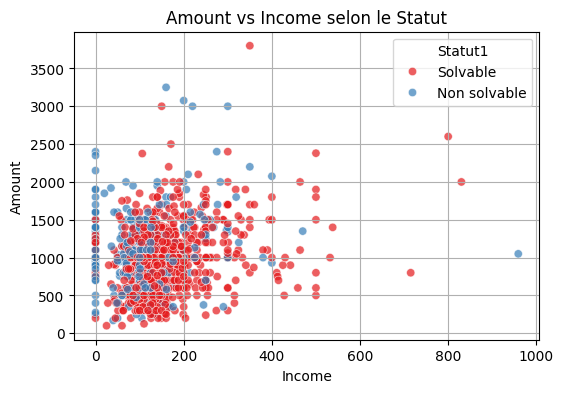

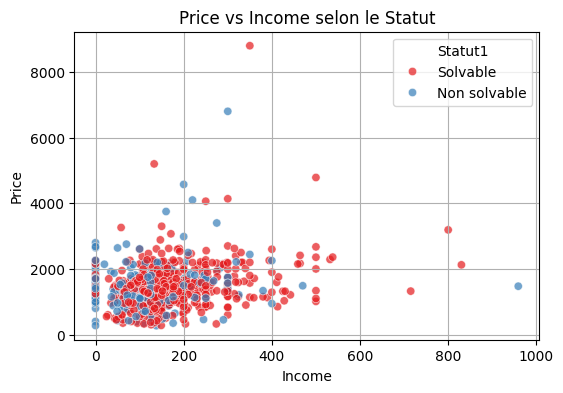

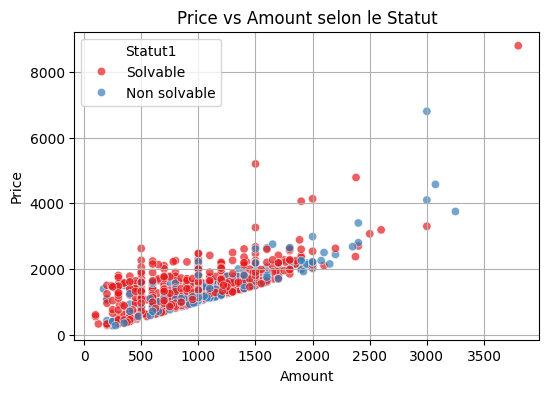

In [70]:
# scatter plots 2D var1 vs var2 selon Statut
from itertools import combinations
# Liste des variables numériques
num_vars = ['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']

# Générer toutes les paires possibles
pairs = list(combinations(num_vars, 2))

# Tracer les scatter plots
for x_var, y_var in pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x_var, y=y_var, hue='Statut1', palette='Set1', alpha=0.7)
    plt.title(f"{y_var} vs {x_var} selon le Statut")
    plt.grid(True)
    plt.show()


## Préparation pour la modélisation

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [72]:
X = df[['Age', 'Marital', 'Expenses', 'Income', 'Amount', 'Price']]
y = df['Statut1']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [73]:
scaler = StandardScaler()

In [74]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Régression logistique

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

In [76]:
model = LogisticRegression(random_state=42)

In [77]:
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [78]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probabilité d'être "Solvable"

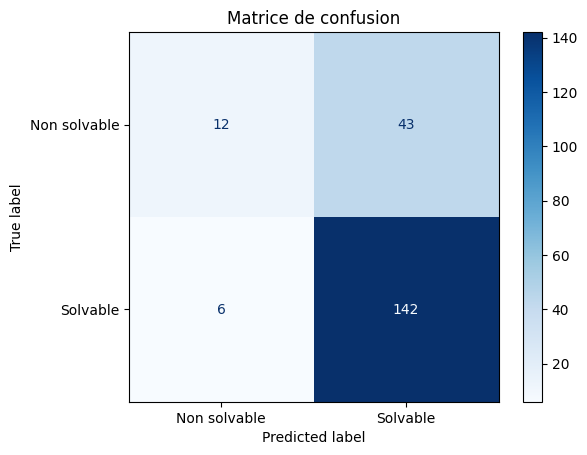

In [79]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non solvable', 'Solvable'])
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

In [80]:
# évaluation du modèle
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.2f}")
print(f"Précision : {precision_score(y_test, y_pred, pos_label='Solvable'):.2f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label='Solvable'):.2f}")
print(f"F1-score  : {f1_score(y_test, y_pred, pos_label='Solvable'):.2f}")


Accuracy  : 0.76
Précision : 0.77
Recall    : 0.96
F1-score  : 0.85


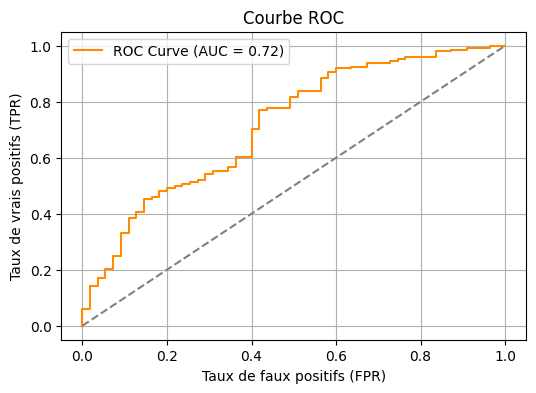

In [81]:
# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label='Solvable')
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

L'AUC de 0,73 indique un modèle de performance moyenne. La courbe au-dessus de la diagonale montre qu'il est meilleur qu'une prédiction aléatoire. Le modèle détecte initialement bien certains positifs avec peu de faux positifs, mais sa précision diminue progressivement.

![Texte_alternatif](metrics.png)


In [82]:
# K-fold cross-validation

In [83]:
from sklearn.model_selection import cross_val_score, cross_validate
import numpy as np

In [84]:
model1 = LogisticRegression(random_state=42)
cv_scores = cross_val_score(model1, X_train_scaled, y_train, cv=5, scoring='accuracy')  
print(f"Scores de la validation croisée (accuracy) sur 5 folds : {cv_scores}")
print(f"Performance moyenne (accuracy) : {np.mean(cv_scores):.4f}")
print(f"Écart-type des scores : {np.std(cv_scores):.4f}")

Scores de la validation croisée (accuracy) sur 5 folds : [0.78527607 0.74233129 0.7345679  0.74074074 0.75308642]
Performance moyenne (accuracy) : 0.7512
Écart-type des scores : 0.0181


## KNN 

In [85]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

Meilleurs paramètres :  {'metric': 'euclidean', 'n_neighbors': 11}
Meilleure précision (accuracy) :  0.7586306142543362
Accuracy sur les données de test :  0.7438423645320197
Matrice de confusion : 
 [[ 13  42]
 [ 10 138]]
Rapport de classification : 
               precision    recall  f1-score   support

Non solvable       0.57      0.24      0.33        55
    Solvable       0.77      0.93      0.84       148

    accuracy                           0.74       203
   macro avg       0.67      0.58      0.59       203
weighted avg       0.71      0.74      0.70       203



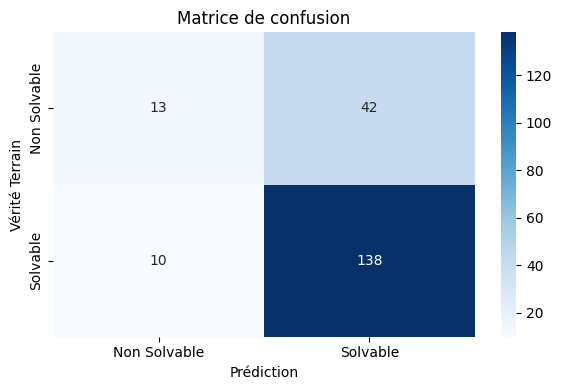

In [86]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],   
    'metric': ['euclidean', 'manhattan', 'chebyshev']  
}
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print("Meilleurs paramètres : ", grid_search.best_params_)

print("Meilleure précision (accuracy) : ", grid_search.best_score_)

# 8. Évaluer le modèle avec les meilleurs paramètres sur les données de test
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

# 9. Calculer les performances du modèle sur les données de test
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy sur les données de test : ", accuracy_score(y_test, y_pred))
print("Matrice de confusion : \n", confusion_matrix(y_test, y_pred))
print("Rapport de classification : \n", classification_report(y_test, y_pred))

# 10. Visualiser la matrice de confusion sous forme de heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Non Solvable', 'Solvable'], yticklabels=['Non Solvable', 'Solvable'])
plt.title('Matrice de confusion')
plt.xlabel('Prédiction')
plt.ylabel('Vérité Terrain')
plt.tight_layout()
plt.show()


## Sauvegarde et réutilisation des modèles

In [87]:
import joblib
import os

In [88]:
model_folder = "C:\\Users\\PARAV\\OneDrive\\Escritorio\\DL_classification_RLOGISTIC_KNN"
joblib.dump(model, os.path.join(model_folder, 'model.pkl'))
joblib.dump(best_knn, os.path.join(model_folder, 'knn_model.pkl'))
joblib.dump(scaler, os.path.join(model_folder, 'scaler.pkl'))
print("Les modèles et le scaler ont été sauvegardés dans le dossier 'Documents'.")

Les modèles et le scaler ont été sauvegardés dans le dossier 'Documents'.


In [89]:
loaded_logistic_model = joblib.load(os.path.join(model_folder, 'model.pkl'))
loaded_knn = joblib.load(os.path.join(model_folder, 'knn_model.pkl'))
loaded_scaler = joblib.load(os.path.join(model_folder, 'scaler.pkl'))

print("Les modèles et le scaler ont été rechargés depuis le dossier 'Documents'.")

Les modèles et le scaler ont été rechargés depuis le dossier 'Documents'.


In [90]:
data = np.array([[45, 1, 100, 200, 800, 1000],  
                 [26, 3, 90, 150, 650, 1600]])
scaled_data = loaded_scaler.transform(data)


predictions_logistique = loaded_logistic_model.predict(scaled_data)
predictions_knn = loaded_knn.predict(scaled_data)


print("Les prédictions pour logistic_models sont :")
print(predictions_logistique )
print("Les prédictions pour knn_models sont :")
print(predictions_knn )

Les prédictions pour logistic_models sont :
['Solvable' 'Solvable']
Les prédictions pour knn_models sont :
['Solvable' 'Solvable']


c:\Users\PARAV\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
